In [1]:
import os, math, time, gc                                                                                                                                                                                 
from pathlib import Path                                                                                                                                                                                  
from collections import defaultdict, Counter                                                                                                                                                              
                                                                                                                                                                                                        
import numpy as np
import pandas as pd                                                                                                                                                                                       
import torch       
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt                 
                                                                                                                                                                                                        
DATA_PATH = "/Users/spartan/Desktop/Music Recommendation/deezer-recsys25"
SAVE_PATH = "/Users/spartan/Desktop/Music Recommendation/Music-Recommendation/cache"                                                                                                                      
os.makedirs(SAVE_PATH, exist_ok=True)                                               
                                                                                                                                                                                                        
if torch.backends.mps.is_available():
    device = torch.device("mps")                                                                                                                                                                          
elif torch.cuda.is_available(): 
    device = torch.device("cuda")                                                                                                                                                                         
else:                            
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
N_SESSION_FILES = 30    # was 20 — 50% more data                                                                                                                                                          
MAX_USERS       = 30000 # was 10k — 3x more users
MIN_SESSIONS    = 5     # was 6 — slightly looser filter, more eligible users                                                                                                                             
SEQ_LEN         = 5                                                          
MAX_SEQ_TRACKS  = 50                                                                                                                                                                                      
                                                                                                                                                                                                        
BATCH_SIZE  = 512   # was 256 — fewer batches per epoch, faster                                                                                                                                           
EPOCHS      = 10    # was 15 — early stopping will cut this short anyway                                                                                                                                  
PATIENCE    = 3     # early stopping patience                           
HIDDEN_DIM  = 256                                                                                                                                                                                         
NUM_LAYERS  = 2  
DROPOUT     = 0.2                                                                                                                                                                                         
LR          = 0.001
SVD_DIM     = 128                                                                                                                                                                                         
AUDIO_DIM   = 1024                                                                                                                                                                                        
PROJ_DIM    = 128 
                                                                                                                                                                                                        
print(f"Subset  : {N_SESSION_FILES}/500 files, top {MAX_USERS} users")                                                                                                                                    
print(f"Training: up to {EPOCHS} epochs (early stop patience={PATIENCE}), batch {BATCH_SIZE}")  

Subset  : 30/500 files, top 30000 users
Training: up to 10 epochs (early stop patience=3), batch 512


In [6]:
print("=== Loading track embeddings ===")                                                                                                                                                                 
t0 = time.time()                         
                
emb_files = sorted(Path(f"{DATA_PATH}/track_embeddings").glob("svd_audio_*"))                                                                                                                             
raw = pd.concat([pd.read_parquet(f) for f in emb_files], ignore_index=True)                                                                                                                               
print(f"Loaded {len(raw)} tracks in {time.time()-t0:.1f}s")                                                                                                                                               
                                                                                                                                                                                                        
def extract_svd(x):
    if isinstance(x, dict) and 'list' in x:                                                                                                                                                               
        return np.array([item['item'] for item in x['list'][:SVD_DIM]], dtype=np.float32)
    return np.array(x, dtype=np.float32)[:SVD_DIM]                                                                                                                                                        
                                                                                                                                                                                                        
svd_lookup   = {r['track_id']: extract_svd(r['svd'])                              for _, r in raw.iterrows()}                                                                                             
audio_lookup = {r['track_id']: np.array(r['audio'], dtype=np.float32)[:AUDIO_DIM] for _, r in raw.iterrows()}                                                                                             
known_tracks = set(svd_lookup.keys())                                                                        
                                                                                                                                                                                                        
print(f"SVD lookup: {len(svd_lookup)} tracks | Audio lookup: {len(audio_lookup)} tracks")
del raw; gc.collect()

=== Loading track embeddings ===
Loaded 50000 tracks in 1.2s
SVD lookup: 50000 tracks | Audio lookup: 50000 tracks


0

In [7]:
sess_files = sorted(Path(f"{DATA_PATH}/user_sessions").glob("sessions_*"))[:N_SESSION_FILES]
print(f"=== Pass 1: counting sessions per user across {len(sess_files)} files ===")         
t0 = time.time()                                                                                                                                                                                          
                                                                                                                                                                                                        
user_session_count = Counter()                                                                                                                                                                            
for i, f in enumerate(sess_files):                                                                                                                                                                        
    # Read only 2 columns — much faster than loading the full file
    df = pd.read_parquet(f, columns=['user_id', 'session_id'])                                                                                                                                            
    counts = df.groupby('user_id')['session_id'].nunique()                                                                                                                                                
    user_session_count.update(counts.to_dict())                                                                                                                                                           
    if (i + 1) % 5 == 0:                                                                                                                                                                                  
        print(f"  Pass 1: {i+1}/{len(sess_files)} files done", end='\r')                                                                                                                                  
    del df; gc.collect()                                                
                                                                                                                                                                                                        
print(f"\nPass 1 done: {len(user_session_count)} unique users  ({time.time()-t0:.1f}s)")
                                                                                                                                                                                                        
# Select top MAX_USERS with enough sessions
eligible = [(u, c) for u, c in user_session_count.items() if c >= MIN_SESSIONS]                                                                                                                           
eligible.sort(key=lambda x: x[1], reverse=True)                                
selected = {u for u, _ in eligible[:MAX_USERS]}                                                                                                                                                           
print(f"Selected {len(selected)} users with {MIN_SESSIONS}+ sessions")
del user_session_count, eligible; gc.collect()                                                                                                                                                            
                                            
print(f"\n=== Pass 2: loading session data for {len(selected)} users ===")                                                                                                                                
t0 = time.time()                                                                                                                                                                                          
                                                                                                                                                                                                        
user_sessions = defaultdict(list)                                                                                                                                                                         
for i, f in enumerate(sess_files):
    df = pd.read_parquet(f, columns=['user_id', 'track_id', 'session_id', 'ts'])
    # Filter early — only selected users AND only tracks that have embeddings   
    df = df[df['user_id'].isin(selected) & df['track_id'].isin(known_tracks)]                                                                                                                             
    if len(df) == 0:                                                                                                                                                                                      
        continue                                                                                                                                                                                          
    df = df.sort_values('ts')                                                                                                                                                                             
    for (u, s), g in df.groupby(['user_id', 'session_id'], sort=False):
        tracks = g.sort_values('ts')['track_id'].tolist()                                                                                                                                                 
        if tracks:                                       
            user_sessions[u].append(tracks)                                                                                                                                                               
    if (i + 1) % 5 == 0:                   
        print(f"  Pass 2: {i+1}/{len(sess_files)} files, {len(user_sessions)} users loaded", end='\r')                                                                                                    
    del df; gc.collect()                                                                              
                                                                                                                                                                                                        
print(f"\nPass 2 done in {time.time()-t0:.1f}s  |  {len(user_sessions)} users with data")

=== Pass 1: counting sessions per user across 30 files ===
  Pass 1: 30/30 files done
Pass 1 done: 3570619 unique users  (19.2s)
Selected 30000 users with 5+ sessions

=== Pass 2: loading session data for 30000 users ===
  Pass 2: 30/30 files, 30000 users loaded
Pass 2 done in 267.3s  |  30000 users with data


In [8]:
print("=== Building training samples ===")
samples    = []                           
all_tracks = set()                                                                                                                                                                                        
                
for user_id in selected:                                                                                                                                                                                  
    sessions = user_sessions.get(user_id, [])                                                                                                                                                             
    if len(sessions) < SEQ_LEN + 1:          
        continue                                                                                                                                                                                          
    for i in range(len(sessions) - SEQ_LEN):
        flat_seq  = [t for sess in sessions[i : i + SEQ_LEN] for t in sess]
        tgt_track = sessions[i + SEQ_LEN][0]                                                                                                                                                              
        all_tracks.update(flat_seq)                                                                                                                                                                       
        all_tracks.add(tgt_track)                                                                                                                                                                         
        samples.append((flat_seq, tgt_track))                                                                                                                                                             
                                                                                                                                                                                                        
print(f"Samples: {len(samples):,}  |  Unique tracks: {len(all_tracks):,}")                                                                                                                                
del user_sessions; gc.collect() 

=== Building training samples ===
Samples: 4,699,708  |  Unique tracks: 35,758


0

In [9]:
print("=== Building vocabulary ===")                                                                                                                                                                      
track_list = sorted(all_tracks)     
track2idx  = {t: i + 1 for i, t in enumerate(track_list)}                                                                                                                                                 
NUM_TRACKS = len(track_list) + 1                         
print(f"Vocabulary: {NUM_TRACKS} tracks")                                                                                                                                                                 
                                        
svd_matrix   = np.zeros((NUM_TRACKS, SVD_DIM),   dtype=np.float32)                                                                                                                                        
audio_matrix = np.zeros((NUM_TRACKS, AUDIO_DIM), dtype=np.float32)
                                                                                                                                                                                                        
for tid, idx in track2idx.items():                                                                                                                                                                        
    if tid in svd_lookup:         
        svd_matrix[idx]   = svd_lookup[tid]                                                                                                                                                               
    if tid in audio_lookup:                
        audio_matrix[idx] = audio_lookup[tid]                                                                                                                                                             
                                            
print(f"SVD matrix: {svd_matrix.shape}  |  Audio matrix: {audio_matrix.shape}")                                                                                                                           
del svd_lookup, audio_lookup; gc.collect()                                     
                                        
conv_samples = []                                                                                                                                                                                         
for flat_seq, tgt in samples:
    seq_idx = [track2idx.get(t, 0) for t in flat_seq]                                                                                                                                                     
    tgt_idx = track2idx.get(tgt, 0)                  
    if tgt_idx > 0:                                                                                                                                                                                       
        conv_samples.append((seq_idx, tgt_idx))
                                                                                                                                                                                                        
print(f"Valid samples: {len(conv_samples):,}")
del samples; gc.collect()

=== Building vocabulary ===
Vocabulary: 35759 tracks
SVD matrix: (35759, 128)  |  Audio matrix: (35759, 1024)
Valid samples: 4,699,708


0

In [10]:
class SessionDataset(Dataset):                                                                                                                                                                            
    def __init__(self, samples, max_len):
        self.samples = samples           
        self.max_len = max_len
    def __len__(self): return len(self.samples)                                                                                                                                                           
    def __getitem__(self, idx):                
        seq, tgt = self.samples[idx]                                                                                                                                                                      
        seq = seq[-self.max_len:] if len(seq) > self.max_len else seq + [0] * (self.max_len - len(seq))
        return torch.tensor(seq, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)                
                                                                                                                                                                                                        
n       = len(conv_samples)                                                                                                                                                                               
n_train = int(0.8 * n)                                                                                                                                                                                    
n_val   = int(0.1 * n)                                                                                                                                                                                    
n_test  = n - n_train - n_val                                                                                                                                                                             
                            
dataset = SessionDataset(conv_samples, MAX_SEQ_TRACKS)                                                                                                                                                    
train_ds, val_ds, test_ds = torch.utils.data.random_split(                                                                                                                                                
    dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42)
)                                                                                                                                                                                                         
                
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)                                                                                                                  
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)                                                                                                                  
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
                                                                                                                                                                                                        
print(f"Train={len(train_ds):,}  Val={len(val_ds):,}  Test={len(test_ds):,}")                                                                                                                             
print(f"Batches/epoch: {len(train_loader)}")                                                                                                                                                              
del conv_samples; gc.collect() 

Train=3,759,766  Val=469,970  Test=469,972
Batches/epoch: 7344


0

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):                                                                                                                                                             
        super().__init__()                                                                                                                                                                                
        pe  = torch.zeros(max_len, d_model)                                                                                                                                                               
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)                                                                                                                                    
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))                                                                                                             
        pe[:, 0::2] = torch.sin(pos * div)                                                                                                                                                                
        pe[:, 1::2] = torch.cos(pos * div)                                                                                                                                                                
        self.register_buffer('pe', pe)
                                                                                                                                                                                                        
    def forward(self, x):                                                                                                                                                                                 
        return x + self.pe[:x.size(1)].unsqueeze(0)
                                                                                                                                                                                                        
                
class LinearAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.W = nn.Linear(dim, dim)
                                                                                                                                                                                                        
    def forward(self, x):
        return (torch.softmax(self.W(x), dim=1) * x).sum(dim=1)                                                                                                                                           
                
                                                                                                                                                                                                        
class AudioOnlyModel(nn.Module):
    def __init__(self, svd_mat, hidden=256, layers=2, dropout=0.2):                                                                                                                                       
        super().__init__()                                                                                                                                                                                
        self.emb  = nn.Embedding.from_pretrained(torch.FloatTensor(svd_mat), padding_idx=0, freeze=False)
        self.pos  = PositionalEncoding(svd_mat.shape[1])                                                                                                                                                  
        self.gru  = nn.GRU(svd_mat.shape[1], hidden, layers, batch_first=True,                                                                                                                            
                            dropout=dropout if layers > 1 else 0)                                                                                                                                          
        self.attn = LinearAttention(hidden)                                                                                                                                                               
        self.drop = nn.Dropout(dropout)                                                                                                                                                                   
        self.fc   = nn.Linear(hidden, svd_mat.shape[0])                                                                                                                                                   

    def forward(self, x):                                                                                                                                                                                 
        out, _ = self.gru(self.pos(self.emb(x)))
        return self.fc(self.drop(self.attn(out)))                                                                                                                                                         

                                                                                                                                                                                                        
class MultimodalModelV2(nn.Module):
    def __init__(self, svd_mat, audio_mat, hidden=256, layers=2, dropout=0.2, proj=128):
        super().__init__()                                                                                                                                                                                
        self.svd_emb   = nn.Embedding.from_pretrained(torch.FloatTensor(svd_mat),   padding_idx=0, freeze=False)
        self.audio_emb = nn.Embedding.from_pretrained(torch.FloatTensor(audio_mat), padding_idx=0, freeze=True)                                                                                           
        mid = audio_mat.shape[1] // 2                                                                                                                                                                     
        self.proj = nn.Sequential(                                                                                                                                                                        
            nn.Linear(audio_mat.shape[1], mid), nn.LayerNorm(mid), nn.ReLU(), nn.Dropout(dropout),                                                                                                        
            nn.Linear(mid, proj), nn.LayerNorm(proj),
        )                                                                                                                                                                                                 
        self.gate = nn.Parameter(torch.zeros(proj))
        self.pos  = PositionalEncoding(proj)                                                                                                                                                              
        self.gru  = nn.GRU(proj, hidden, layers, batch_first=True,                                                                                                                                        
                            dropout=dropout if layers > 1 else 0)
        self.attn = LinearAttention(hidden)                                                                                                                                                               
        self.drop = nn.Dropout(dropout)                                                                                                                                                                   
        self.fc   = nn.Linear(hidden, svd_mat.shape[0])
                                                                                                                                                                                                        
    def forward(self, x):
        svd_n   = F.normalize(self.svd_emb(x),               dim=-1)
        audio_n = F.normalize(self.proj(self.audio_emb(x)),   dim=-1)                                                                                                                                     
        alpha   = torch.sigmoid(self.gate)                                                                                                                                                                
        fused   = alpha * svd_n + (1 - alpha) * audio_n                                                                                                                                                   
        out, _  = self.gru(self.pos(fused))                                                                                                                                                               
        return self.fc(self.drop(self.attn(out)))
                                                                                                                                                                                                        
    @property   
    def svd_weight(self):                                                                                                                                                                                 
        return torch.sigmoid(self.gate).mean().item()

                                                                                                                                                                                                        
print("Models defined: AudioOnlyModel, MultimodalModelV2")

Models defined: AudioOnlyModel, MultimodalModelV2


In [18]:
def evaluate(model, loader, ks=(10, 20)):
    model.eval()                                                                                                                                                                                          
    hits  = {k: 0   for k in ks}
    dcg   = {k: 0.0 for k in ks}                                                                                                                                                                          
    total = 0   
    with torch.no_grad():
        for seq, tgt in loader:                                                                                                                                                                           
            seq, tgt = seq.to(device), tgt.to(device)
            logits   = model(seq)                                                                                                                                                                         
            for k in ks:
                topk = logits.topk(k, dim=1).indices
                for j in range(len(tgt)):                                                                                                                                                                 
                    t = tgt[j].item(); row = topk[j].tolist()
                    if t in row:                                                                                                                                                                          
                        hits[k] += 1
                        dcg[k]  += 1.0 / math.log2(row.index(t) + 2)
            total += len(tgt)                                                                                                                                                                             
    return {f"recall@{k}": hits[k]/total for k in ks}, {f"ndcg@{k}": dcg[k]/total for k in ks}, total
                                                                                                                                                                                                        
                
def train_model(model, name):                                                                                                                                                                             
    criterion = nn.CrossEntropyLoss()
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR * 0.05)                                                                                                              

    history    = {"loss": [], "recall@10": [], "recall@20": [], "ndcg@10": [], "ndcg@20": []}                                                                                                             
    best_r10   = 0.0
    no_improve = 0                                                                                                                                                                                        
    ckpt_path  = f"{SAVE_PATH}/{name}_v3_best.pt"
    t0         = time.time()                                                                                                                                                                              

    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")                                                                                                                                                      
                
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for bi, (seq, tgt) in enumerate(train_loader):                                                                                                                                                    
            seq, tgt = seq.to(device), tgt.to(device)
            opt.zero_grad()                                                                                                                                                                               
            loss = criterion(model(seq), tgt)
            loss.backward()                                                                                                                                                                               
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()                                                                                                                                                                                    
            running_loss += loss.item()
            if bi % 100 == 0:
                print(f"  E{epoch+1:02d} B{bi:04d}/{len(train_loader)} loss={loss.item():.4f}", end='\r')
                                                                                                                                                                                                        
        sched.step()
        avg_loss = running_loss / len(train_loader)                                                                                                                                                       
        recall, ndcg, _ = evaluate(model, val_loader)
        r10 = recall["recall@10"]                                                                                                                                                                         

        for k in history:                                                                                                                                                                                 
            history[k].append(avg_loss if k == "loss" else (recall.get(k) or ndcg.get(k)))
                                                                                                                                                                                                        
        marker = ""
        if r10 > best_r10:                                                                                                                                                                                
            best_r10 = r10; no_improve = 0
            torch.save(model.state_dict(), ckpt_path); marker = "  *** BEST ***"
        else:                                                                                                                                                                                             
            no_improve += 1
                                                                                                                                                                                                        
        extra = f"  gate(SVD)={model.svd_weight:.3f}" if hasattr(model, 'svd_weight') else ""
        print(f"  E{epoch+1:02d}/{EPOCHS} loss={avg_loss:.4f}  R@10={r10:.4f}  "
            f"R@20={recall['recall@20']:.4f}  NDCG@10={ndcg['ndcg@10']:.4f}  "                                                                                                                          
            f"t={(time.time()-t0)/60:.1f}min{extra}{marker}")                                                                                                                                           
                                                                                                                                                                                                        
        if no_improve >= PATIENCE:                                                                                                                                                                        
            print(f"  Early stopping (no improvement for {PATIENCE} epochs)"); break
                                                                                                                                                                                                        
    print(f"\nBest Val R@10: {best_r10:.4f}  |  {ckpt_path}")
    return history, best_r10                                                                                                                                                                              
                

print("Training functions ready.")

Training functions ready.


In [19]:
ao_model = AudioOnlyModel(svd_matrix, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)                                                                                                                         
print(f"AudioOnly params: {sum(p.numel() for p in ao_model.parameters()):,}")    
ao_history, ao_best = train_model(ao_model, "audio_only")

AudioOnly params: 14,524,207

Training: audio_only
  E01/10 loss=8.1552  R@10=0.0370  R@20=0.0642  NDCG@10=0.0177  t=62.4min  *** BEST ***
  E02/10 loss=7.9882  R@10=0.0392  R@20=0.0688  NDCG@10=0.0187  t=146.0min  *** BEST ***
  E03/10 loss=7.9315  R@10=0.0412  R@20=0.0709  NDCG@10=0.0197  t=210.3min  *** BEST ***
  E04/10 loss=7.8870  R@10=0.0424  R@20=0.0729  NDCG@10=0.0202  t=275.3min  *** BEST ***
  E05/10 loss=7.8462  R@10=0.0430  R@20=0.0738  NDCG@10=0.0206  t=340.3min  *** BEST ***
  E06/10 loss=7.8074  R@10=0.0439  R@20=0.0748  NDCG@10=0.0210  t=405.2min  *** BEST ***
  E07/10 loss=7.7693  R@10=0.0440  R@20=0.0754  NDCG@10=0.0211  t=470.0min  *** BEST ***
  E08/10 loss=7.7350  R@10=0.0446  R@20=0.0759  NDCG@10=0.0214  t=534.8min  *** BEST ***
  E09/10 loss=7.7073  R@10=0.0448  R@20=0.0763  NDCG@10=0.0214  t=599.8min  *** BEST ***
  E10/10 loss=7.6878  R@10=0.0450  R@20=0.0765  NDCG@10=0.0216  t=664.7min  *** BEST ***

Best Val R@10: 0.0450  |  /Users/spartan/Desktop/Music Reco

In [20]:
mm_model = MultimodalModelV2(svd_matrix, audio_matrix, HIDDEN_DIM, NUM_LAYERS, DROPOUT, PROJ_DIM).to(device)
trainable = sum(p.numel() for p in mm_model.parameters() if p.requires_grad)                                                                                                                              
print(f"MultimodalV2 — trainable: {trainable:,}")                                                                                                                                                         
mm_history, mm_best = train_model(mm_model, "multimodal_v2")

MultimodalV2 — trainable: 15,116,079

Training: multimodal_v2
  E01/10 loss=8.2821  R@10=0.0307  R@20=0.0544  NDCG@10=0.0146  t=76.4min  gate(SVD)=0.624  *** BEST ***
  E02/10 loss=8.0569  R@10=0.0364  R@20=0.0639  NDCG@10=0.0174  t=152.9min  gate(SVD)=0.685  *** BEST ***
  E03/10 loss=7.9762  R@10=0.0392  R@20=0.0685  NDCG@10=0.0187  t=292.5min  gate(SVD)=0.711  *** BEST ***
  E04/10 loss=7.9227  R@10=0.0404  R@20=0.0701  NDCG@10=0.0193  t=373.8min  gate(SVD)=0.722  *** BEST ***
  E05/10 loss=7.8781  R@10=0.0413  R@20=0.0714  NDCG@10=0.0198  t=455.0min  gate(SVD)=0.728  *** BEST ***
  E06/10 loss=7.8375  R@10=0.0424  R@20=0.0730  NDCG@10=0.0203  t=538.0min  gate(SVD)=0.731  *** BEST ***
  E07/10 loss=7.8009  R@10=0.0424  R@20=0.0727  NDCG@10=0.0203  t=621.3min  gate(SVD)=0.733  *** BEST ***
  E08/10 loss=7.7679  R@10=0.0431  R@20=0.0736  NDCG@10=0.0206  t=704.8min  gate(SVD)=0.734  *** BEST ***
  E09/10 loss=7.7422  R@10=0.0434  R@20=0.0739  NDCG@10=0.0207  t=787.4min  gate(SVD)=0.735

In [21]:
ao_model.load_state_dict(torch.load(f"{SAVE_PATH}/audio_only_v3_best.pt",     map_location=device))                                                                                                       
mm_model.load_state_dict(torch.load(f"{SAVE_PATH}/multimodal_v2_v3_best.pt",  map_location=device))
                                                                                                                                                                                                        
ao_recall, ao_ndcg, n_test_total = evaluate(ao_model, test_loader)                                                                                                                                        
mm_recall, mm_ndcg, _            = evaluate(mm_model, test_loader)                                                                                                                                        
ao_m = {**ao_recall, **ao_ndcg}                                                                                                                                                                           
mm_m = {**mm_recall, **mm_ndcg}                                                                                                                                                                           
                                                                                                                                                                                                        
print(f"\nTest samples: {n_test_total:,}")
print(f"\n{'Metric':<14} {'Audio-Only':>14} {'Multimodal V2':>14} {'Δ':>10}")                                                                                                                             
print("-" * 54)                                                              
for m in ['recall@10', 'recall@20', 'ndcg@10', 'ndcg@20']:                                                                                                                                                
    ao_v = ao_m[m]; mm_v = mm_m[m]                        
    rel  = (mm_v - ao_v) / ao_v * 100 if ao_v > 0 else 0                                                                                                                                                  
    print(f"{m.upper():<14} {ao_v:>14.4f} {mm_v:>14.4f}  {rel:>+.1f}%")
                                                                                                                                                                                                        
print(f"\nLearned gate — SVD: {mm_model.svd_weight:.3f}  Audio: {1-mm_model.svd_weight:.3f}")


Test samples: 469,972

Metric             Audio-Only  Multimodal V2          Δ
------------------------------------------------------
RECALL@10              0.0448         0.0434  -3.3%
RECALL@20              0.0764         0.0740  -3.1%
NDCG@10                0.0216         0.0208  -3.6%
NDCG@20                0.0295         0.0285  -3.4%

Learned gate — SVD: 0.736  Audio: 0.264


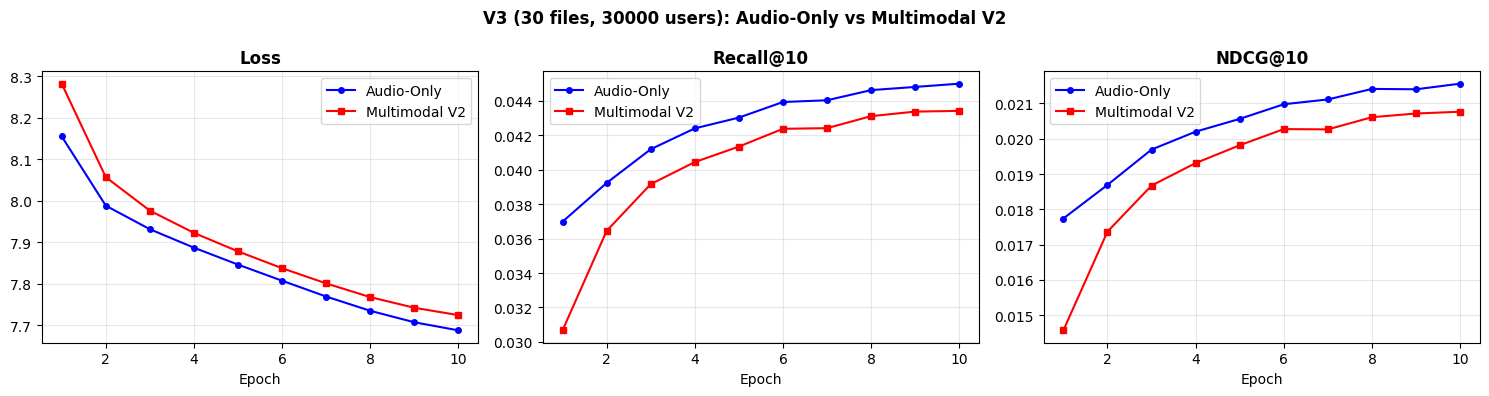

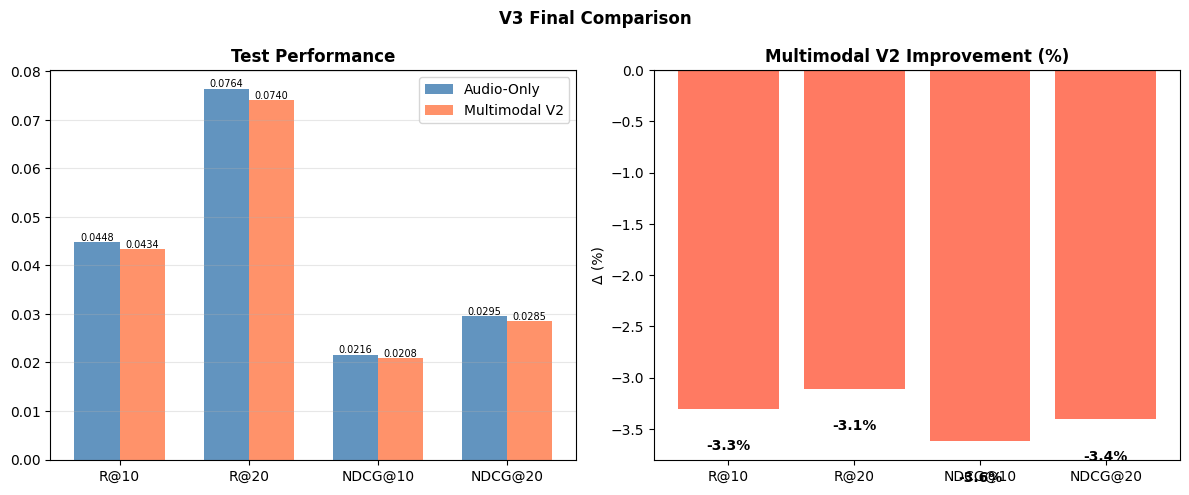

In [22]:
ep = list(range(1, len(ao_history["loss"]) + 1))                                                                                                                                                          
ep_mm = list(range(1, len(mm_history["loss"]) + 1))
                                                                                                                                                                                                        
fig, axes = plt.subplots(1, 3, figsize=(15, 4))                                                                                                                                                           
for ax, key, title in zip(axes, ["loss","recall@10","ndcg@10"], ["Loss","Recall@10","NDCG@10"]):
    ax.plot(ep,    ao_history[key], "b-o", markersize=4, label="Audio-Only")                                                                                                                              
    ax.plot(ep_mm, mm_history[key], "r-s", markersize=4, label="Multimodal V2")                                                                                                                           
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Epoch")                                                                                                                                        
    ax.legend(); ax.grid(True, alpha=0.3)                                                                                                                                                                 
                                                                                                                                                                                                        
plt.suptitle(f"V3 ({N_SESSION_FILES} files, {MAX_USERS} users): Audio-Only vs Multimodal V2", fontsize=12, fontweight="bold")                                                                             
plt.tight_layout()                                                                                                                                                                                        
plt.savefig(f"{SAVE_PATH}/v3_curves.png", dpi=150, bbox_inches="tight")                                                                                                                                   
plt.show()                                                                                                                                                                                                
                
# Bar chart                                                                                                                                                                                               
labels = ["R@10","R@20","NDCG@10","NDCG@20"]
keys   = ["recall@10","recall@20","ndcg@10","ndcg@20"]                                                                                                                                                    
ao_v   = [ao_m[k] for k in keys]                                                                                                                                                                          
mm_v   = [mm_m[k] for k in keys]
improv = [(m-a)/a*100 if a>0 else 0 for a,m in zip(ao_v, mm_v)]                                                                                                                                           
                                                                
fig, axes = plt.subplots(1, 2, figsize=(12, 5))                                                                                                                                                           
x, w = np.arange(len(labels)), 0.35                                                                                                                                                                       
b1 = axes[0].bar(x-w/2, ao_v, w, label="Audio-Only",    color="steelblue", alpha=0.85)                                                                                                                    
b2 = axes[0].bar(x+w/2, mm_v, w, label="Multimodal V2", color="coral",     alpha=0.85)                                                                                                                    
axes[0].set_title("Test Performance", fontweight="bold")                                                                                                                                                  
axes[0].set_xticks(x); axes[0].set_xticklabels(labels); axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")                                                                                         
for bar in list(b1)+list(b2):                                                                                                                                                                             
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003, f"{bar.get_height():.4f}", ha="center", fontsize=7)                                                                              
                                                                                                                                                                                                        
axes[1].bar(labels, improv, color=["seagreen" if v>=0 else "tomato" for v in improv], alpha=0.85)                                                                                                         
axes[1].axhline(0, color="black", lw=0.8)                                                                                                                                                                 
axes[1].set_title("Multimodal V2 Improvement (%)", fontweight="bold"); axes[1].set_ylabel("Δ (%)")                                                                                                        
for i, v in enumerate(improv):                                                                                                                                                                            
    axes[1].text(i, v+(0.1 if v>=0 else -0.4), f"{v:+.1f}%", ha="center", fontweight="bold", fontsize=10)
                                                                                                                                                                                                        
plt.suptitle("V3 Final Comparison", fontsize=12, fontweight="bold")                                                                                                                                       
plt.tight_layout()                                                                                                                                                                                        
plt.savefig(f"{SAVE_PATH}/v3_comparison.png", dpi=150, bbox_inches="tight")                                                                                                                               
plt.show()